# 03. Limpieza y Alineamiento Estructural

## Pipeline de Procesamiento: 3 Objetivos de Calidad

### Objetivo 1: LIMPIEZA
- Eliminar heteroátomos (HETATM): ligandos, agua, iones metálicos, cofactores
- Mantener solo líneas ATOM (residuos proteicos estándar)
- Eliminar residuos incompletos (< átomos mínimos)
- Validar coordenadas (rango razonable)

### Objetivo 2: ESTANDARIZACIÓN
- Identificar residuos comunes por posición entre PDB y AlphaFold
- Mantener solo átomos backbone: **N, CA, C, O, CB**
- Garantizar que ambas estructuras tienen exactamente los mismos átomos

### Objetivo 3: SUPERPOSICIÓN
- Alinear tridimensionalmente las estructuras (rotación + traslación)
- Minimizar la distancia entre átomos correspondientes
- Calcular RMSD (Root Mean Square Deviation)

$$RMSD = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\|\mathbf{r}_i^{PDB} - \mathbf{r}_i^{AF}\|^2}$$

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.PDB import PDBParser, Superimposer

from alphafold_comparison.config import Config
from alphafold_comparison.preprocessing.processor import QualityProcessor

## Demostración con un Par Individual

Procesamos un par paso a paso para entender qué hace cada etapa.

In [2]:
# Cargar indice
if Config.ID_LIST.exists():
    id_list = pd.read_csv(Config.ID_LIST)
    # Tomar un ejemplo
    example = id_list.iloc[0]
    pdb_id = example['PDB']
    uniprot_id = example['SP_PRIMARY']
    print(f"Par ejemplo: PDB={pdb_id}, UniProt={uniprot_id}")
    
    pdb_file = Config.PDB_DIR / f"pdb{pdb_id.lower()}.ent"
    af_file = Config.AF_DIR / f"{uniprot_id}.pdb"
    print(f"PDB existe: {pdb_file.exists()}")
    print(f"AlphaFold existe: {af_file.exists()}")

Par ejemplo: PDB=7WJI, UniProt=Q9P2D8
PDB existe: True
AlphaFold existe: True


In [3]:
# Procesar el par usando la API interna correcta
from alphafold_comparison.preprocessing.processor import (
    _build_sifts_index, _init_worker, _process_pair_worker
)

processor = QualityProcessor()
sifts_index = processor._load_sifts()
_init_worker(sifts_index)

result = _process_pair_worker((
    pdb_id, uniprot_id,
    processor.min_residues,
    processor.min_atoms_per_res,
    processor.min_alignment_atoms
))

print("Resultado del procesamiento:")
for k, v in result.items():
    print(f"  {k}: {v}")

Cargando indice SIFTS desde /home/antonio-tapia/alphafold-project/data/raw/mappings/pdb_chain_uniprot.csv...


  422,870 pares indexados (17.1s)


Resultado del procesamiento:
  pdb_id: 7WJI
  uniprot_id: Q9P2D8
  success: True
  error: None
  chain_id: B
  matched_residues: 1663
  rmsd: 72.94872568632704
  pdb_residues: 1663
  af_residues: 2635


## Estadísticas del Procesamiento Completo

Revisamos los resultados del procesamiento de todos los pares.

In [4]:
# Cargar indice de calidad
if Config.QUALITY_INDEX.exists():
    quality_df = pd.read_csv(Config.QUALITY_INDEX)
    print(f"Pares certificados: {len(quality_df):,}")
    print(f"Columnas: {list(quality_df.columns)}")
    print(f"\nEstadisticas de RMSD:")
    print(quality_df['rmsd'].describe())
    print(f"\nEstadisticas de residuos alineados (matched_residues):")
    print(quality_df['matched_residues'].describe())
else:
    print("Ejecutar: make process")

Pares certificados: 10,432
Columnas: ['pair_id', 'pdb_id', 'uniprot_id', 'chain_id', 'matched_residues', 'rmsd', 'quality_certified']

Estadisticas de RMSD:
count    10432.000000
mean         3.561578
std         10.409913
min          0.045751
25%          0.657940
50%          1.255193
75%          3.023722
max        855.737293
Name: rmsd, dtype: float64

Estadisticas de residuos alineados (matched_residues):
count    10432.000000
mean       271.516871
std        229.487635
min          3.000000
25%        123.000000
50%        221.000000
75%        352.000000
max       2371.000000
Name: matched_residues, dtype: float64


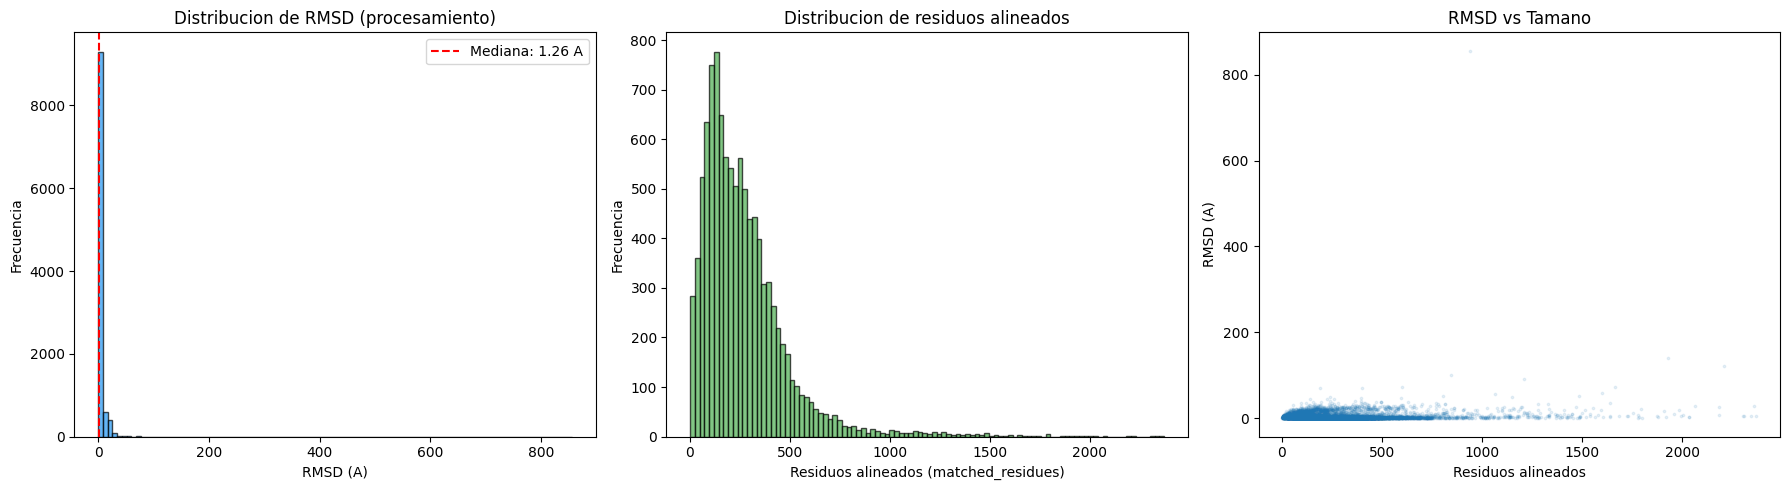

In [5]:
# Visualizar distribucion de RMSD del procesamiento
if Config.QUALITY_INDEX.exists():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # RMSD
    axes[0].hist(quality_df['rmsd'], bins=100, edgecolor='black', alpha=0.7, color='#2196F3')
    axes[0].axvline(quality_df['rmsd'].median(), color='red', linestyle='--',
                    label=f"Mediana: {quality_df['rmsd'].median():.2f} A")
    axes[0].set_xlabel('RMSD (A)')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_title('Distribucion de RMSD (procesamiento)')
    axes[0].legend()
    
    # Residuos alineados
    axes[1].hist(quality_df['matched_residues'], bins=100, edgecolor='black', alpha=0.7, color='#4CAF50')
    axes[1].set_xlabel('Residuos alineados (matched_residues)')
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Distribucion de residuos alineados')
    
    # RMSD vs residuos alineados
    axes[2].scatter(quality_df['matched_residues'], quality_df['rmsd'], alpha=0.1, s=3)
    axes[2].set_xlabel('Residuos alineados')
    axes[2].set_ylabel('RMSD (A)')
    axes[2].set_title('RMSD vs Tamano')
    
    plt.tight_layout()
    plt.savefig('figures/procesamiento_stats.png', dpi=150, bbox_inches='tight')
    plt.show()

## ¿Por qué falla el 39% de los pares?

De ~23,671 pares descargados, solo ~14,311 pasan el control de calidad. Las razones principales son:
- Archivos PDB no parseables (corrupted, formato no estándar)
- Insuficientes residuos comunes entre las dos estructuras
- Estructuras demasiado pequeñas (<3 residuos)
- Errores de superposición (átomos insuficientes para alinear)

## Siguiente Paso

→ [04_analisis_estructural.ipynb](04_analisis_estructural.ipynb): Análisis estadístico de los 14,311 pares procesados.